In [28]:
import pandas as  pd 
import matplotlib.pyplot as plt 
import numpy as np
from SFstarred.utils import plot_image_and_noisemap
from SFstarred.save_and_read import read_hdf5_to_dict

In [29]:
# a function that generates a model instance and initial guess parameters:
from starred.deconvolution.deconvolution import setup_model
# a parameters handler:
from starred.deconvolution.parameters import ParametersDeconv
# the loss function, basically chi² + regularization
from starred.deconvolution.loss import Loss
# the interface to the optimizer:
from starred.optim.optimization import Optimizer
# a way to propagate the noisemap through starlet layers:
from starred.utils.noise_utils import propagate_noise
# a plot utility to explore our deconvolution at every step
from starred.plots.plot_function import view_deconv_model

In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
data_f160W = pd.read_pickle("data_for_starred/data_for_starred_F160_0214.pickle")

## We know try to deconvolve the images

In [248]:

narrow_psfs = np.load('narrows_psfs/f160_narrow_psfs.npy')

if len(narrow_psfs.shape)==2:
	narrow_psfs = narrow_psfs[None,:]

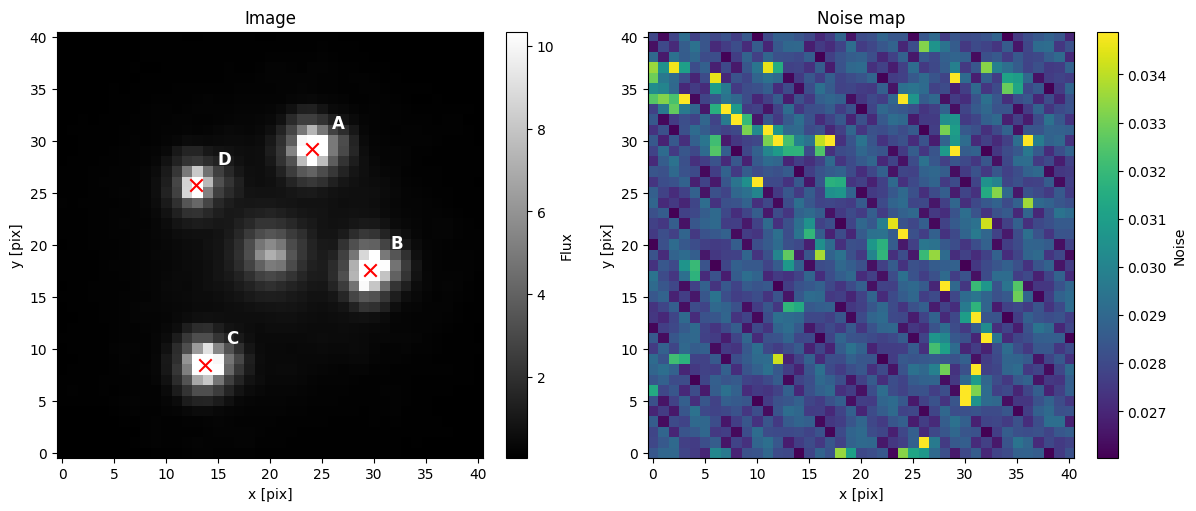

(1, 41, 41) (1, 41, 41)
[ 9.60743656  4.01177314 -6.20281186 -7.0881054 ]
[ -2.39260519   9.18362889 -11.53556347   5.7310841 ]


In [250]:
data = data_f160W["data"]#['data_cutout']
noisemaps = data_f160W['data_noisemaps']#['sigma2']
image_positions = data_f160W["coord_pix_images"]
image_names = data_f160W["images_names"]
coord_pix_images_dict = data_f160W["coord_pix_images_dict"]
fig, ax = plot_image_and_noisemap(
    data=data[0],
    noisemaps=noisemaps[0],
    image_positions=image_positions,
    image_names=image_names,
    vmin=np.nanpercentile(data, 1),
    vmax=np.nanpercentile(data, 99),
    noise_vmin=np.nanpercentile(noisemaps, 1),
    noise_vmax=np.nanpercentile(noisemaps, 99),
)
plt.show()
im_size = data.shape[1]
offset = (im_size-1) / 2.
# while we're at it extract the x and y positions separately
xs = image_positions[:,0] - offset

ys = image_positions[:,1] - offset

# xs = np.array([coord_pix_images_dict[name][0] for name in 'ABCD']) - offset
# ys = np.array([coord_pix_images_dict[name][1] for name in 'ABCD']) - offset

brightnesses = len(data) * 4 * [np.max(data)]
print(data.shape,noisemaps.shape)
np.median(data[0]),np.median(noisemaps[0])
print(xs)
print(ys)

In [253]:
model, k_init, k_up, k_down, k_fixed = setup_model(data=data, 
                                                   sigma_2=noisemaps**2, 
                                                   s=narrow_psfs, 
                                                   xs=xs,
                                                   ys=ys,
                                                   initial_a=brightnesses,
                                                   subsampling_factor=2)

In [254]:
k_fixed['kwargs_background']['h'] = k_init['kwargs_background']['h']

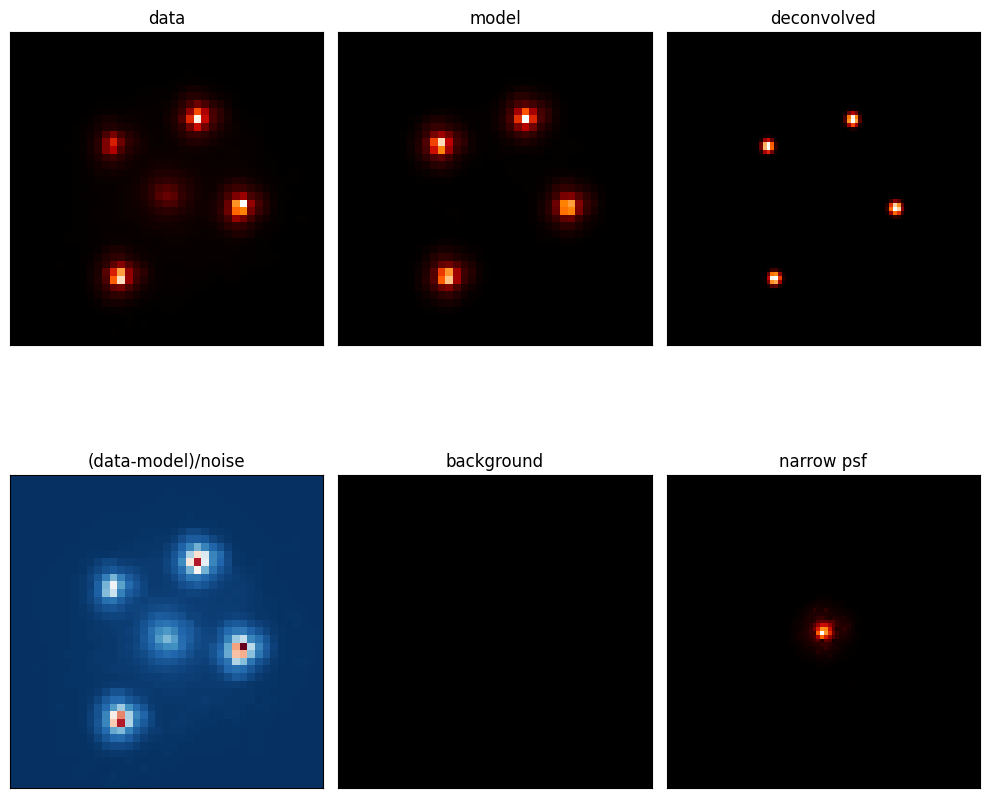

In [255]:
view_deconv_model(model, k_init, data, noisemaps**2, figsize=(10,10))

In [256]:
 # the params needs the initial guess, fixed params and boundaries:
params = ParametersDeconv(k_init, k_fixed, k_up, k_down)
# the loss needs to see our data, noisemaps, model, and the params class:
loss = Loss(data, model, params, noisemaps**2)
# now we can make an optimizer!
optim = Optimizer(loss, params, method='l-bfgs-b')

In [257]:
# optimize (this returns some metrics, but we don't need them here.)
optim.minimize(maxiter=70)
# the best fit is automatically given to the params:
k_optim = params.best_fit_values(as_kwargs=True)

In [258]:
k_optim

{'kwargs_analytic': {'a': Array([11.224314, 10.062769, 10.257962,  6.060211], dtype=float32),
  'c_x': Array([ 9.65107  ,  4.022917 , -6.1761856, -7.0684247], dtype=float32),
  'c_y': Array([ -2.3302116,   9.164833 , -11.537052 ,   5.738113 ], dtype=float32),
  'dx': Array([0.], dtype=float32),
  'dy': Array([0.], dtype=float32),
  'alpha': Array([0.], dtype=float32)},
 'kwargs_background': {'mean': Array([0.06144637], dtype=float32),
  'h': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)},
 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32),
  'R_sersic': Array([], shape=(0,), dtype=float32),
  'n_sersic': Array([], shape=(0,), dtype=float32),
  'center_x': Array([], shape=(0,), dtype=float32),
  'center_y': Array([], shape=(0,), dtype=float32),
  'e1': Array([], shape=(0,), dtype=float32),
  'e2': Array([], shape=(0,), dtype=float32)}}

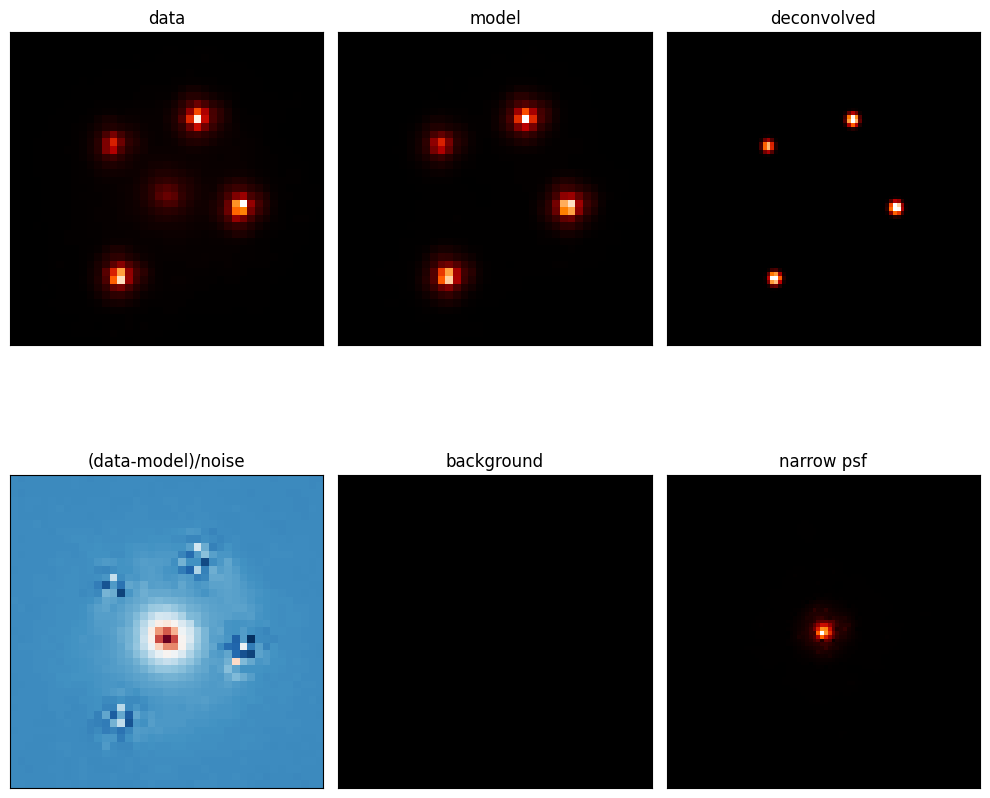

In [259]:
view_deconv_model(model, k_optim, data, noisemaps**2, figsize=(10,10))

In [260]:
 # remove the background fixing:
del k_fixed['kwargs_background']['h']
# calculate the propagation of the noise:
W = propagate_noise(model, noisemaps, k_init, upsampling_factor=2)[0]

In [261]:
# start from our optimized params of before
params = ParametersDeconv(k_optim, k_fixed, k_up, k_down)
# this time we provide the noise scaling to the loss
loss = Loss(data, model, params, noisemaps**2, W=W)
# new optimizer!
optim = Optimizer(loss, params, method='l-bfgs-b')
# let's go directly:
optim.minimize(maxiter=30)
k_optim_with_background = params.best_fit_values(as_kwargs=True).copy()

In [262]:
params.best_fit_values(as_kwargs=True)

{'kwargs_analytic': {'a': Array([11.269375 , 10.077595 , 10.481829 ,  6.1439457], dtype=float32),
  'c_x': Array([ 9.668177 ,  4.016817 , -6.1843987, -7.0777593], dtype=float32),
  'c_y': Array([ -2.301895 ,   9.162532 , -11.545095 ,   5.7815576], dtype=float32),
  'dx': Array([0.], dtype=float32),
  'dy': Array([0.], dtype=float32),
  'alpha': Array([0.], dtype=float32)},
 'kwargs_background': {'mean': Array([0.04870053], dtype=float32),
  'h': Array([-0.04941377, -0.05768185, -0.06014025, ..., -0.05071623,
         -0.04556216, -0.03610094], dtype=float32)},
 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32),
  'R_sersic': Array([], shape=(0,), dtype=float32),
  'n_sersic': Array([], shape=(0,), dtype=float32),
  'center_x': Array([], shape=(0,), dtype=float32),
  'center_y': Array([], shape=(0,), dtype=float32),
  'e1': Array([], shape=(0,), dtype=float32),
  'e2': Array([], shape=(0,), dtype=float32)}}

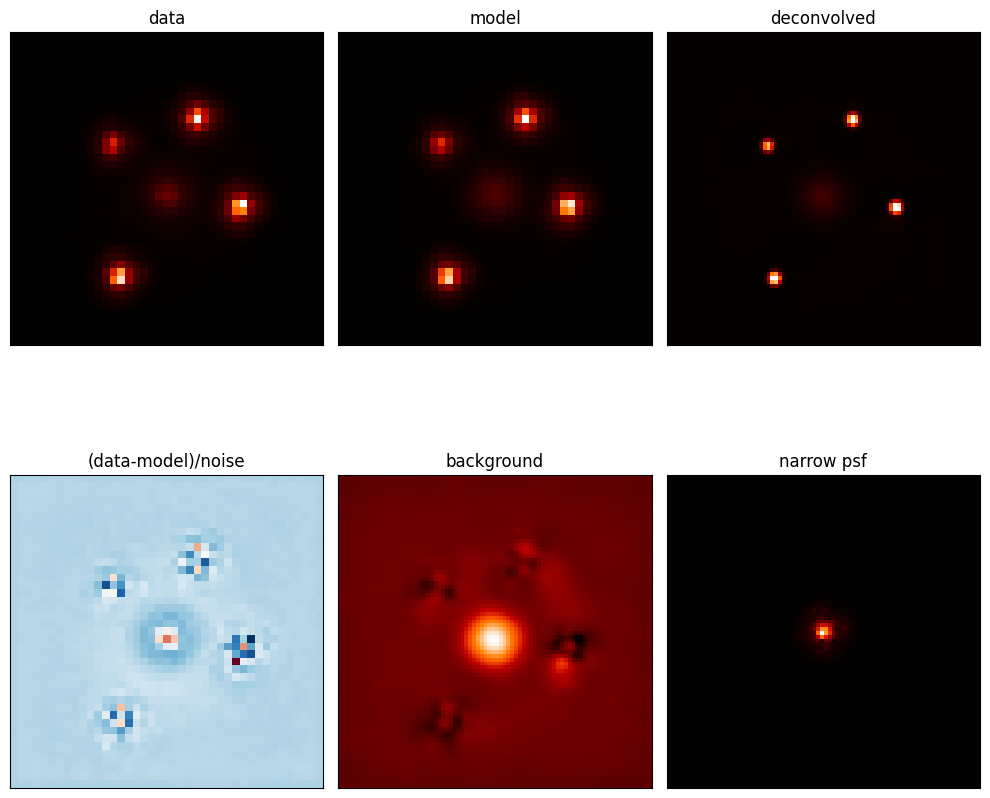

In [263]:
view_deconv_model(model, k_optim_with_background, data, noisemaps**2, figsize=(10,10))